In [2]:
# === Imports ===
import numpy as np
import pandas as pd
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [26]:
#Read in file
df = pd.read_csv("Life_Expectancy.csv")
df.head()

,Year,County_Name,State_Name,diversity,smoking,obesity,house_income,unemployment_rate,pct_edu_or_health,life_expectancy
0,2022,Autauga County,Alabama,43.28,0.159327,0.347826,68315,2.768472,0.199500,76.585650
1,2022,Baldwin County,Alabama,31.17,0.193452,-0.478261,71039,3.443495,0.192394,77.724729
2,2022,Barbour County,Alabama,57.83,1.541364,1.086957,39712,5.753791,0.207643,72.867210
3,2022,Bibb County,Alabama,40.49,1.097747,1.202899,50669,8.706247,0.200073,73.609363
4,2022,Blount County,Alabama,25.55,0.585882,0.840580,57440,5.969585,0.199952,74.171463


In [27]:
#PartA, Calculate mean and st dev for life expectancy column
mean_le = df["life_expectancy"].mean()
std_le  = df["life_expectancy"].std()
mean_le, std_le

(np.float64(76.8871037489716), np.float64(3.265839037336975))

In [28]:
#PartB, Define function that caclulates if county's life expectancy is Long, Short, or Average
def life_exp(value):
    if pd.isna(value):
        return np.nan
    if value > mean_le + std_le:
        return "Long"
    elif value < mean_le - std_le:
        return "Short"
    else:
        return "Average"

#Create new column("Category")
df["category"] = df["life_expectancy"].apply(life_exp)
df.head()

,Year,County_Name,State_Name,diversity,smoking,obesity,house_income,unemployment_rate,pct_edu_or_health,life_expectancy,category
0,2022,Autauga County,Alabama,43.28,0.159327,0.347826,68315,2.768472,0.199500,76.585650,Average
1,2022,Baldwin County,Alabama,31.17,0.193452,-0.478261,71039,3.443495,0.192394,77.724729,Average
2,2022,Barbour County,Alabama,57.83,1.541364,1.086957,39712,5.753791,0.207643,72.867210,Short
3,2022,Bibb County,Alabama,40.49,1.097747,1.202899,50669,8.706247,0.200073,73.609363,Short
4,2022,Blount County,Alabama,25.55,0.585882,0.840580,57440,5.969585,0.199952,74.171463,Average


In [29]:
#PartC, Filter out only Short and Long categories
df_binary = df[df["category"].isin(["Short", "Long"])].copy()

# Display counts
print(df_binary["category"].value_counts())

category
Short    415
Long     403
Name: count, dtype: int64


In [30]:
#PartD, Convert "Short" → 0 and "Long" → 1
y = label_binarize(df_binary["category"], classes=["Short", "Long"]).ravel()
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [31]:
#PartE, Drop non‑predictive columns
cols_to_drop = ["Year", "County_Name", "State_Name", "life_expectancy"]

df_model = df_binary.drop(columns=cols_to_drop, errors="ignore")
df_model.head()


,diversity,smoking,obesity,house_income,unemployment_rate,pct_edu_or_health,category
2,57.83,1.541364,1.086957,39712,5.753791,0.207643,Short
3,40.49,1.097747,1.202899,50669,8.706247,0.200073,Short
6,54.18,0.995374,0.985507,44429,6.813378,0.188259,Short
7,45.38,0.654131,0.434783,54339,6.946770,0.225781,Short
12,53.07,1.063623,1.666667,47549,12.459529,0.214386,Short


In [25]:
X = df[['diversity','smoking','obesity','house_income','unemployment_rate','pct_edu_or_health']]
X

,diversity,smoking,obesity,house_income,unemployment_rate,pct_edu_or_health
0,43.28,0.159327,0.347826,68315,2.768472,0.199500
1,31.17,0.193452,-0.478261,71039,3.443495,0.192394
2,57.83,1.541364,1.086957,39712,5.753791,0.207643
3,40.49,1.097747,1.202899,50669,8.706247,0.200073
4,25.55,0.585882,0.840580,57440,5.969585,0.199952
...,...,...,...,...,...,...
3139,36.61,-0.301351,0.086957,79375,5.711328,0.217518
3140,34.11,-1.273896,-1.550725,108279,2.093023,0.174782
3141,23.66,0.005768,-0.449275,78164,3.423897,0.271805
3142,31.29,-0.198978,-0.579710,61875,1.785272,0.249179


In [32]:

# 1) Build X and y exactly as requested
# --------------------------------------------------------------------------
feature_cols = [
    "diversity",
    "smoking",
    "obesity",
    "house_income",
    "unemployment_rate",
    "pct_edu_or_health",
]

# Check features exist
missing = [c for c in feature_cols if c not in df_binary.columns]
if missing:
    raise KeyError(f"Missing required feature columns: {missing}")

# Coerce to numeric and drop rows with any NaNs in features
X = df_binary[feature_cols].apply(pd.to_numeric, errors="coerce")
X = X.dropna(axis=0, how="any")

# Align y with X (Short->0, Long->1)
y = label_binarize(df_binary.loc[X.index, "category"], classes=["Short", "Long"]).ravel()

# --------------------------------------------------------------------------
# 2) Define models and grids
# --------------------------------------------------------------------------
# KNN grid
knn = KNeighborsClassifier()
param_grid_knn = {
    "n_neighbors": [3, 5],
    "metric": ["euclidean", "manhattan"],
}

grid_knn = GridSearchCV(
    estimator=knn,
    param_grid=param_grid_knn,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    return_train_score=False,
)

# Decision Tree grid
dt = DecisionTreeClassifier(random_state=0)
param_grid_dt = {
    "max_depth": [5, None],
    "min_samples_split": [5, 10],
}

grid_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid_dt,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    return_train_score=False,
)


In [33]:

# 3) Fit the grid searches
# --------------------------------------------------------------------------
grid_knn.fit(X, y)
grid_dt.fit(X, y)



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.11/site-packages/joblib/externals/loky/backend/popen_loky_posix.py", line 180, in <module>
    exitcode = process_obj._bootstrap()
  File "/usr/local/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/usr/local/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.11

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, None], 'min_samples_split': [5, 10]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 

In [34]:

# 4) Present cv_results_ as tidy pandas DataFrames
# --------------------------------------------------------------------------
def tidy_results(grid):
    df_res = pd.DataFrame(grid.cv_results_)
    cols = ["params", "mean_test_score", "std_test_score", "rank_test_score"]
    return df_res[cols].sort_values(
        by=["rank_test_score", "mean_test_score"], ascending=[True, False]
    ).reset_index(drop=True)

print("KNN Grid Search Results:")
try:
    display(tidy_results(grid_knn))  # Jupyter-friendly
except NameError:
    print(tidy_results(grid_knn).to_string(index=False))

print("\nDecision Tree Grid Search Results:")
try:
    display(tidy_results(grid_dt))   # Jupyter-friendly
except NameError:
    print(tidy_results(grid_dt).to_string(index=False))

# --------------------------------------------------------------------------
# 5) Final markdown-style summary of the overall best model
# --------------------------------------------------------------------------
best_model_name = "KNN" if grid_knn.best_score_ >= grid_dt.best_score_ else "DecisionTree"
best_grid = grid_knn if best_model_name == "KNN" else grid_dt

summary_md = (
    "\n---\n"
    "### **Model with Highest ROC AUC (5-fold CV)**\n\n"
    f"1) **Model**: {best_model_name}\n\n"
    f"2) **Best Parameters**: `{best_grid.best_params_}`\n\n"
    f"3) **Mean CV ROC AUC**: **{best_grid.best_score_:.4f}**\n"
)
print(summary_md)


KNN Grid Search Results:


,params,mean_test_score,std_test_score,rank_test_score
0,"{'metric': 'manhattan', 'n_neighbors': 5}",0.942863,0.013017,1
1,"{'metric': 'euclidean', 'n_neighbors': 5}",0.940775,0.015322,2
2,"{'metric': 'manhattan', 'n_neighbors': 3}",0.929845,0.018433,3
3,"{'metric': 'euclidean', 'n_neighbors': 3}",0.927807,0.018384,4



Decision Tree Grid Search Results:


,params,mean_test_score,std_test_score,rank_test_score
0,"{'max_depth': None, 'min_samples_split': 10}",0.957078,0.016116,1
1,"{'max_depth': 5, 'min_samples_split': 10}",0.954826,0.019634,2
2,"{'max_depth': None, 'min_samples_split': 5}",0.949918,0.018825,3
3,"{'max_depth': 5, 'min_samples_split': 5}",0.945549,0.015133,4



---
### **Model with Highest ROC AUC (5-fold CV)**

1) **Model**: DecisionTree

2) **Best Parameters**: `{'max_depth': None, 'min_samples_split': 10}`

3) **Mean CV ROC AUC**: **0.9571**



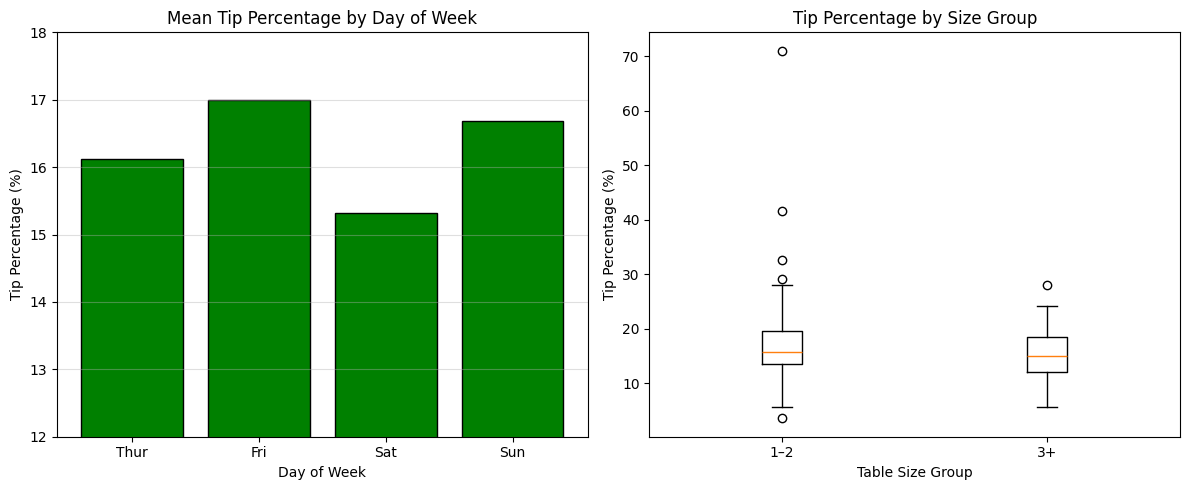

In [2]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Load tips dataset ---
df = sns.load_dataset("tips")

# --- Create tip percentage column (as percent, not proportion) ---
df["tip_pct"] = df["tip"] / df["total_bill"] * 100

# --- Compute mean tip percentage by day for the left bar chart ---
mean_by_day = df.groupby("day")["tip_pct"].mean()

# --- Create a "group" column based on party size (1–2 vs 3+) ---
# NOTE: the en-dash below matches your instructions: "1–2"
df["group"] = df["size"].apply(lambda x: "1–2" if x <= 2 else "3+")

# --- Prepare the two Series for the right boxplot (only tip_pct column) ---
group1 = df.loc[df["group"] == "1–2", "tip_pct"]
group2 = df.loc[df["group"] == "3+",  "tip_pct"]

# --- Build side-by-side figure ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# ===== Left: Mean Tip Percentage by Day of Week (green bars, grid, ylim) =====
ax1.bar(mean_by_day.index, mean_by_day.values, color="green", edgecolor="black")
ax1.set_title("Mean Tip Percentage by Day of Week")
ax1.set_xlabel("Day of Week")
ax1.set_ylabel("Tip Percentage (%)")
ax1.set_ylim(12, 18)               # as required
ax1.grid(True, axis="y", alpha=0.4) # grid on the left chart

# ===== Right: Boxplot by size group (1–2 vs 3+) =====
# Use the two Series as the data source, set tick labels, label axes, and title
ax2.boxplot([group1, group2], tick_labels=["1–2", "3+"])
ax2.set_ylabel("Tip Percentage (%)")
ax2.set_xlabel("Table Size Group")         # required: set_xlabel
ax2.set_title("Tip Percentage by Size Group")  # required: set_title

plt.tight_layout()
plt.show()